# Telco Customer Churn Modeling

This notebook builds and evaluates machine learning models to predict customer churn using the Telco Customer Churn dataset. The main focus is not only accuracy, but also ROC-AUC, churn recall, churn precision, F1-score, and threshold selection for retention campaigns.

In [56]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

This cell imports the modeling toolkit. The goal is to compare interpretable and tree-based classifiers in a reproducible pipeline so that preprocessing, training, and evaluation follow the same structure.

In [57]:
current_dir = Path.cwd().resolve()

if current_dir.name == "churn_prediction":
    PROJECT_DIR = current_dir
elif "churn_prediction" in current_dir.parts:
    PROJECT_DIR = current_dir
    while PROJECT_DIR.name != "churn_prediction":
        PROJECT_DIR = PROJECT_DIR.parent
elif (current_dir / "projects" / "churn_prediction").exists():
    PROJECT_DIR = current_dir / "projects" / "churn_prediction"
else:
    raise FileNotFoundError("Could not locate the churn_prediction project folder.")

DATA_PATH = PROJECT_DIR / "data" / "processed" / "churn_clean.csv"
DATA_PATH

WindowsPath('D:/Self Project/SumoPod API/Profile/projects/churn_prediction/data/processed/churn_clean.csv')

This cell locates the processed churn dataset generated by `prepare_data.py`. Using processed data keeps the modeling workflow consistent with the documented cleaning and feature engineering steps.

In [58]:
df = pd.read_csv(DATA_PATH)

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,monthly_charges,total_charges,churn,is_churned,has_internet_service,has_month_to_month_contract,has_automatic_payment,avg_monthly_total_ratio,tenure_group,monthly_charge_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,29.85,No,0,1,1,0,29.850000,0-12 months,low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,56.95,1889.50,No,0,1,0,0,55.573529,25-48 months,medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,53.85,108.15,Yes,1,1,1,0,54.075000,0-12 months,medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,42.30,1840.75,No,0,1,0,1,40.905556,25-48 months,medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,70.70,151.65,Yes,1,1,1,0,75.825000,0-12 months,high


The processed dataset is loaded into a dataframe. The target is `is_churned`, where 1 represents a churned customer and 0 represents a retained customer.

In [59]:
df["is_churned"].value_counts(normalize=True).mul(100).round(2)

is_churned
0    73.46
1    26.54
Name: proportion, dtype: float64

The target distribution shows that churn is imbalanced. Because most customers do not churn, accuracy alone can be misleading. Churn recall, precision, F1-score, and ROC-AUC are more useful for evaluating this business problem.

In [60]:
target = "is_churned"

feature_cols = [
    "gender",
    "senior_citizen",
    "partner",
    "dependents",
    "tenure",
    "phone_service",
    "multiple_lines",
    "internet_service",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "contract",
    "paperless_billing",
    "payment_method",
    "monthly_charges",
    "total_charges",
    "has_internet_service",
    "has_month_to_month_contract",
    "has_automatic_payment",
    "avg_monthly_total_ratio",
    "tenure_group",
    "monthly_charge_group",
]

X = df[feature_cols]
y = df[target]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_features, categorical_features

(['senior_citizen',
  'tenure',
  'monthly_charges',
  'total_charges',
  'has_internet_service',
  'has_month_to_month_contract',
  'has_automatic_payment',
  'avg_monthly_total_ratio'],
 ['gender',
  'partner',
  'dependents',
  'phone_service',
  'multiple_lines',
  'internet_service',
  'online_security',
  'online_backup',
  'device_protection',
  'tech_support',
  'streaming_tv',
  'streaming_movies',
  'contract',
  'paperless_billing',
  'payment_method',
  'tenure_group',
  'monthly_charge_group'])

The selected features describe customer profile, service usage, contract type, payment behavior, and billing. The raw `churn` column is excluded because it is the direct source of the target and would create data leakage.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((5634, 25),
 (1409, 25),
 np.float64(0.2653532126375577),
 np.float64(0.2654364797728886))

The dataset is split into training and test sets using stratification. This keeps the churn proportion similar in both sets, making model evaluation more reliable.

In [62]:
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

Two preprocessing strategies are prepared. Logistic Regression uses scaled numeric features, while tree-based models can use numeric features without scaling. Categorical features are one-hot encoded in both cases.

In [63]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", scaled_preprocessor),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ]
    ),
    "Extra Trees": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", ExtraTreesClassifier(
                n_estimators=500,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )),
        ]
    ),
    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]
    ),
    "HistGradientBoosting": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", HistGradientBoostingClassifier(random_state=42, max_iter=300)),
        ]
    ),
}

models.keys()

dict_keys(['Logistic Regression', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'HistGradientBoosting'])

Several models are compared to understand which algorithm performs best on this churn problem. Logistic Regression provides an interpretable baseline, while tree-based models can capture non-linear relationships.

In [64]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.50).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=[1],
        zero_division=0,
    )

    best_threshold = {"threshold": 0.50, "precision": float(precision[0]), "recall": float(recall[0]), "f1": float(f1[0])}

    for threshold in np.arange(0.20, 0.71, 0.01):
        threshold_pred = (y_proba >= threshold).astype(int)
        p, r, f, _ = precision_recall_fscore_support(
            y_test,
            threshold_pred,
            labels=[1],
            zero_division=0,
        )
        if f[0] > best_threshold["f1"]:
            best_threshold = {
                "threshold": round(float(threshold), 2),
                "precision": float(p[0]),
                "recall": float(r[0]),
                "f1": float(f[0]),
            }

    return {
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "precision_churn@0.5": float(precision[0]),
        "recall_churn@0.5": float(recall[0]),
        "f1_churn@0.5": float(f1[0]),
        "best_threshold": best_threshold["threshold"],
        "best_precision_churn": best_threshold["precision"],
        "best_recall_churn": best_threshold["recall"],
        "best_f1_churn": best_threshold["f1"],
    }, y_proba

This evaluation function measures model performance at the default threshold of 0.50 and also searches for a better threshold based on churn F1-score. Threshold tuning matters because retention campaigns often prefer higher churn recall.

In [65]:
results = []
probabilities = {}
trained_models = {}

for model_name, model in models.items():
    result, y_proba = evaluate_model(model_name, model, X_train, X_test, y_train, y_test)
    results.append(result)
    probabilities[model_name] = y_proba
    trained_models[model_name] = model

model_comparison = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
model_comparison.round(4)

,model,roc_auc,precision_churn@0.5,recall_churn@0.5,f1_churn@0.5,best_threshold,best_precision_churn,best_recall_churn,best_f1_churn
0,Gradient Boosting,0.8435,0.6713,0.5134,0.5818,0.28,0.5315,0.7888,0.6351
1,Logistic Regression,0.8418,0.4992,0.7968,0.6138,0.59,0.5528,0.7273,0.6282
2,Random Forest,0.8383,0.5679,0.6818,0.6197,0.45,0.5569,0.7460,0.6377
3,Extra Trees,0.8296,0.5397,0.7086,0.6127,0.49,0.5348,0.7193,0.6135
4,HistGradientBoosting,0.8200,0.5938,0.5160,0.5522,0.30,0.5432,0.6898,0.6078


The comparison table summarizes model performance. With the Telco dataset, several models reach ROC-AUC above 0.80 without data leakage, which is a valid improvement over the previous e-commerce churn dataset.

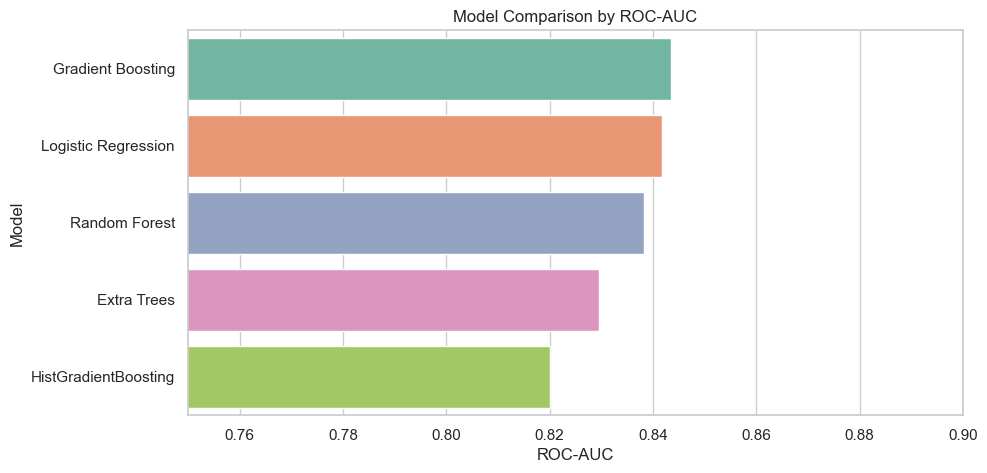

In [66]:
plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison, x="roc_auc", y="model", hue="model", palette="Set2", legend=False)
plt.title("Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.xlim(0.75, 0.90)
plt.show()

**Business Insight:**

ROC-AUC above 0.80 means the model can meaningfully separate churned customers from retained customers. This makes the model useful as a prioritization tool for retention campaigns.

In [67]:
best_model_name = model_comparison.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_proba = probabilities[best_model_name]
best_threshold = model_comparison.iloc[0]["best_threshold"]

best_model_name, best_threshold

('Gradient Boosting', np.float64(0.28))

The best model is selected based on ROC-AUC, while the selected threshold is based on churn F1-score. This separates ranking quality from the business decision threshold.

In [68]:
best_pred_default = (best_proba >= 0.50).astype(int)
best_pred_threshold = (best_proba >= best_threshold).astype(int)

print(f"Best model: {best_model_name}")
print(f"ROC-AUC: {roc_auc_score(y_test, best_proba):.4f}")
print()
print("Classification report at threshold 0.50:")
print(classification_report(y_test, best_pred_default))
print()
print(f"Classification report at threshold {best_threshold}:")
print(classification_report(y_test, best_pred_threshold))

Best model: Gradient Boosting
ROC-AUC: 0.8435

Classification report at threshold 0.50:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409


Classification report at threshold 0.28:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



The classification report compares the default threshold with the selected threshold. Lowering the threshold increases churn recall, which helps identify more at-risk customers, but it also reduces precision.

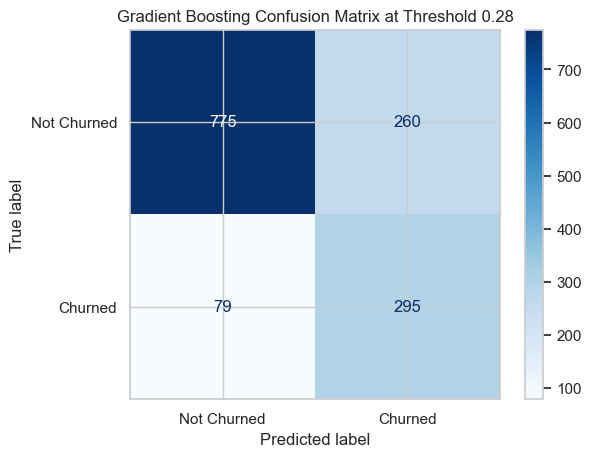

In [69]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred_threshold,
    display_labels=["Not Churned", "Churned"],
    cmap="Blues",
)
plt.title(f"{best_model_name} Confusion Matrix at Threshold {best_threshold}")
plt.show()

The confusion matrix translates model performance into business outcomes: correctly retained customers, false alarms, missed churners, and correctly detected churners.

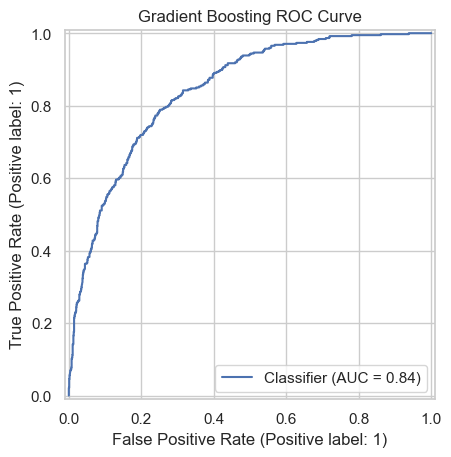

In [70]:
RocCurveDisplay.from_predictions(y_test, best_proba)
plt.title(f"{best_model_name} ROC Curve")
plt.show()

The ROC curve shows model performance across many thresholds. A larger area under the curve means the model is better at ranking churn risk.

In [71]:
business_summary = f"""
The best model is {best_model_name} with ROC-AUC of {roc_auc_score(y_test, best_proba):.3f}.
At the selected threshold of {best_threshold}, the model balances churn recall and precision better than the default threshold.

Business interpretation:
- Customers with month-to-month contracts, short tenure, high monthly charges, and electronic check payment are more likely to churn.
- The model can be used to prioritize retention campaigns for high-risk customers.
- The threshold can be adjusted depending on campaign cost and tolerance for false positives.
"""

print(business_summary)


The best model is Gradient Boosting with ROC-AUC of 0.844.
At the selected threshold of 0.28, the model balances churn recall and precision better than the default threshold.

Business interpretation:
- Customers with month-to-month contracts, short tenure, high monthly charges, and electronic check payment are more likely to churn.
- The model can be used to prioritize retention campaigns for high-risk customers.
- The threshold can be adjusted depending on campaign cost and tolerance for false positives.



## Modeling Summary

The Telco dataset produces a much stronger and more valid churn model than the previous e-commerce churn dataset. Several models achieve ROC-AUC above 0.80 without using target leakage.

Key takeaways:

1. The target `is_churned` is clear and valid.
2. Features such as contract type, tenure, monthly charges, payment method, and service usage provide strong business signal.
3. The best model reaches ROC-AUC around 0.84.
4. Threshold tuning improves the balance between churn recall and precision.
5. The model is ready to be saved, documented, and integrated into the portfolio case study.